In [1]:
import re
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.dates as mdates
import os

path = Path("/Users/thunthita/LidarNRBPipeline/LIDar/src/OutputPictCSV/CSVeachday/")

START_DATE_STR = "02-02-2026"
END_DATE_STR   = "06-02-2026"
DATE_FORMAT = "%d-%m-%Y"

start_date = pd.to_datetime(START_DATE_STR, format=DATE_FORMAT)
end_date   = pd.to_datetime(END_DATE_STR, format=DATE_FORMAT)

# --------------------------------------------------
# Date extractor (DD-MM-YYYY anywhere in filename)
# --------------------------------------------------
def extract_date_from_filename(fname):
    m = re.search(r"\d{2}-\d{2}-\d{4}", fname)
    if not m:
        return None
    return pd.to_datetime(m.group(), format="%d-%m-%Y")

# --------------------------------------------------
# Select only 19–23 Jan 2026 files
# --------------------------------------------------
files = []
for f in path.glob("*.csv"):
    d = extract_date_from_filename(f.name)
    if d is not None and start_date <= d <= end_date:
        files.append((f, d))

files = sorted(files, key=lambda x: x[1])

print("Files to read:")
for f, d in files:
    print(f.name, "->", d.date())

# --------------------------------------------------
# Read + concat
# --------------------------------------------------
dfs = []
for f, d in files:
    df = pd.read_csv(f)
    df["date"] = d
    dfs.append(df)

df = pd.concat(dfs, ignore_index=True)

# --------------------------------------------------
# Reorder columns: date | range_m | time...
# --------------------------------------------------
df.insert(0, "date", df.pop("date"))
df.insert(1, "range_m", df.pop("range_m"))

print("Final shape:", df.shape)
print("Dates loaded:", df["date"].unique())

Files to read:
02-02-2026.csv -> 2026-02-02
03-02-2026.csv -> 2026-02-03
04-02-2026.csv -> 2026-02-04
05-02-2026.csv -> 2026-02-05
06-02-2026.csv -> 2026-02-06
Final shape: (20000, 50)
Dates loaded: <DatetimeArray>
['2026-02-02 00:00:00', '2026-02-03 00:00:00', '2026-02-04 00:00:00',
 '2026-02-05 00:00:00', '2026-02-06 00:00:00']
Length: 5, dtype: datetime64[us]


In [2]:
df

,date,range_m,00.05,00.35,01.05,01.35,02.05,02.35,03.05,03.35,...,19.05,19.35,20.05,20.35,21.05,21.35,22.05,22.35,23.05,23.35
0,2026-02-02,0.00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,2026-02-02,3.75,0.000030,0.000060,0.000032,0.000079,0.000053,0.000045,0.000097,0.000047,...,0.000044,0.000119,0.000051,0.000093,0.000073,0.000071,0.000061,0.000078,0.000057,0.000048
2,2026-02-02,7.50,0.000145,0.000400,0.000155,0.000635,0.000334,0.000256,0.000901,0.000278,...,0.000254,0.001202,0.000314,0.000853,0.000567,0.000533,0.000410,0.000619,0.000372,0.000291
3,2026-02-02,11.25,0.000366,0.001223,0.000393,0.001953,0.000991,0.000718,0.002702,0.000787,...,0.000723,0.004073,0.000942,0.002668,0.001830,0.001642,0.001211,0.001887,0.001136,0.000872
4,2026-02-02,15.00,0.000650,0.002172,0.000698,0.003466,0.001759,0.001276,0.004795,0.001396,...,0.001284,0.007233,0.001673,0.004737,0.003251,0.002913,0.002150,0.003349,0.002017,0.001550
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,2026-02-06,14981.25,0.113614,0.001938,-0.088010,-0.100391,-0.104716,0.089034,-0.012306,0.072420,...,-0.006986,-0.001771,-0.098313,0.183223,-0.004984,0.078393,-0.099717,-0.096715,0.081740,-0.106717
19996,2026-02-06,14985.00,-0.115043,-0.093788,-0.088055,-0.009299,0.083195,-0.108495,-0.116187,0.072456,...,-0.088011,-0.096224,0.165101,0.088234,-0.087045,-0.102607,-0.011695,-0.096764,0.081781,-0.006753
19997,2026-02-06,14988.75,-0.115101,0.001940,-0.088099,-0.100492,-0.010792,-0.108549,-0.012318,0.154523,...,-0.088055,-0.096273,0.077318,-0.101980,-0.004989,-0.012094,-0.011701,-0.004765,0.081822,-0.006756
19998,2026-02-06,14992.50,-0.000687,-0.093882,0.069462,-0.100542,0.083278,-0.108604,-0.116303,-0.009543,...,-0.088099,-0.096321,-0.010552,-0.102031,-0.087133,-0.012100,0.076455,-0.096861,-0.087715,-0.006759


In [3]:
# --- make sure date is datetime ---
df["date"] = pd.to_datetime(df["date"], errors="coerce")

# --- select date range (inclusive) ---
mask = df["date"].between(start_date, end_date, inclusive="both")

df_sel = df.loc[mask].copy()

# --- find time columns (everything except date, range_m) ---
time_cols = [c for c in df_sel.columns if c not in ("date", "range_m")]

# --- make sure range is numeric ---
df_sel["range_m"] = pd.to_numeric(df_sel["range_m"], errors="coerce")

# for t in time_cols:
#     # ensure signal is numeric
#     df_sel[t] = pd.to_numeric(df_sel[t], errors="coerce")

#     fig, ax = plt.subplots(figsize=(6, 8), clear=True)

#     for d, g in df_sel.groupby("date"):
#         gg = g.dropna(subset=[t, "range_m"])
#         ax.plot(
#             gg[t].to_numpy(dtype=float),
#             gg["range_m"].to_numpy(dtype=float),
#             label=d.strftime("%Y-%m-%d"),
#         )

#     ax.invert_yaxis()
#     ax.set_xlabel("Signal")          # "Range Square" sounded mismatched
#     ax.set_ylabel("Range (m)")
#     ax.set_title(f"Range vs Signal at {t}")
#     ax.legend()
#     plt.show()

#     # --- correct debug for numeric data ---
#     print("\n---", t, "---")
#     print("dtype:", df_sel[t].dtype)
#     print("NaNs:", int(df_sel[t].isna().sum()))
#     print("min/max:", df_sel[t].min(), df_sel[t].max())


In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# --- make sure date is datetime ---
df = df.copy()
df["date"] = pd.to_datetime(df["date"], errors="coerce")

# --- select date range (inclusive) ---
mask = df["date"].between(start_date, end_date, inclusive="both")
df_sel = df.loc[mask].copy()

# --- make sure range is numeric ---
df_sel["range_m"] = pd.to_numeric(df_sel["range_m"], errors="coerce")

# --- time tags every 3 hours (choose .05 OR .35 depending on what your file has) ---
time_tags_3h = [f"{h:02d}.05" for h in range(0, 24, 3)]
# time_tags_3h = [f"{h:02d}.35" for h in range(0, 24, 3)]

# --- plot: one figure per day ---
# for day, gday in df_sel.groupby(df_sel["date"].dt.date):

#     fig, axes = plt.subplots(2, 4, figsize=(14, 8), sharey=True, clear=True)
#     axes = axes.ravel()

#     for i, t in enumerate(time_tags_3h):
#         ax = axes[i]

#         if t not in gday.columns:
#             ax.text(0.5, 0.5, f"Missing: {t}", ha="center", va="center")
#             ax.set_title(t)
#             ax.invert_yaxis()
#             continue

#         gg = gday.dropna(subset=["range_m", t]).copy()
#         gg[t] = pd.to_numeric(gg[t], errors="coerce")
#         gg = gg.dropna(subset=["range_m", t])

#         ax.plot(gg[t].to_numpy(float), gg["range_m"].to_numpy(float))
#         ax.set_title(t)
#         ax.set_xlabel("Photon counting (counts/bin)")
#         if i % 4 == 0:
#             ax.set_ylabel("Range (m)")
#         ax.invert_yaxis()
#         ax.grid(True, alpha=0.2)

#     fig.suptitle(f"{day} — Photon counting every 3 hours", y=0.98)
#     fig.tight_layout(rect=[0, 0, 1, 0.95])
#     plt.show()

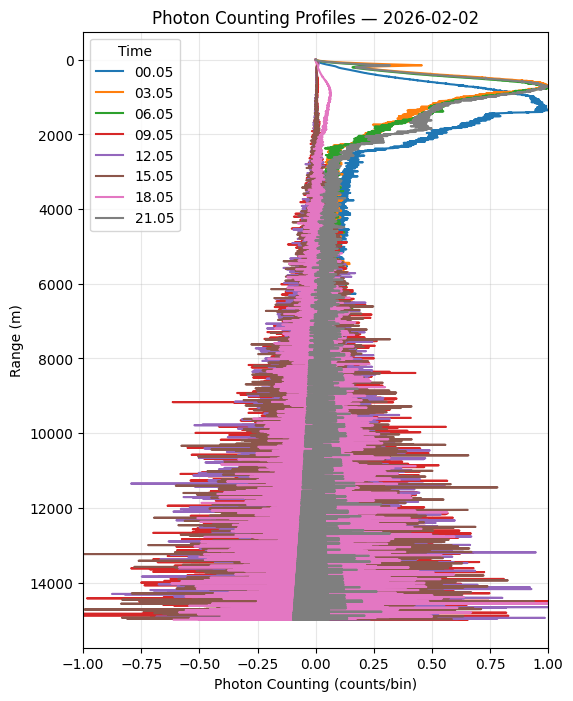

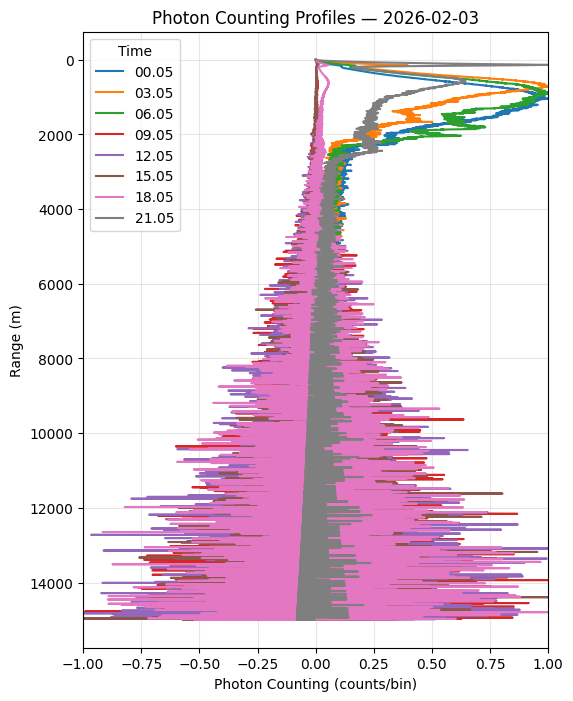

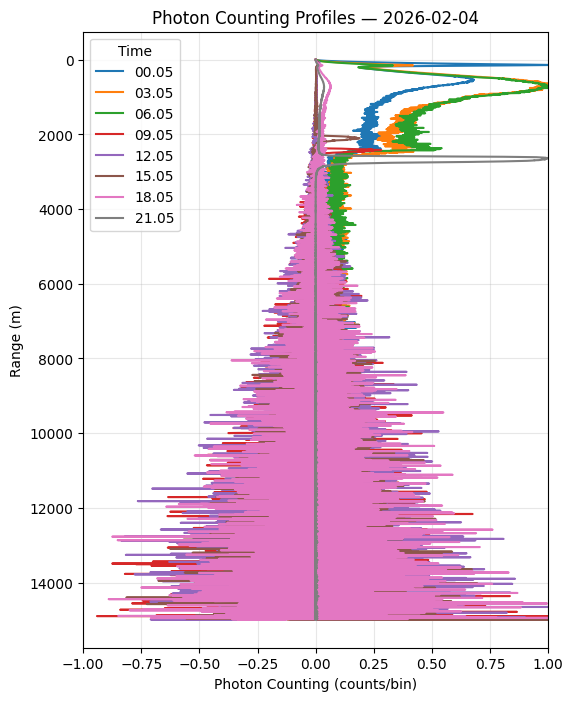

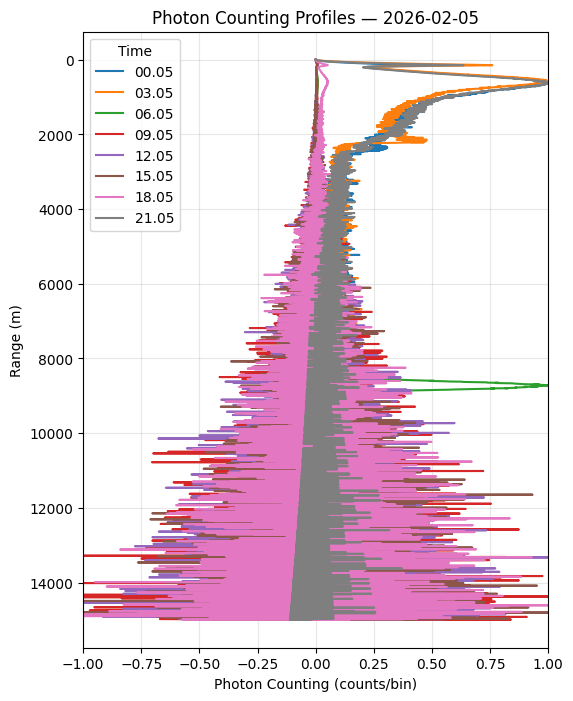

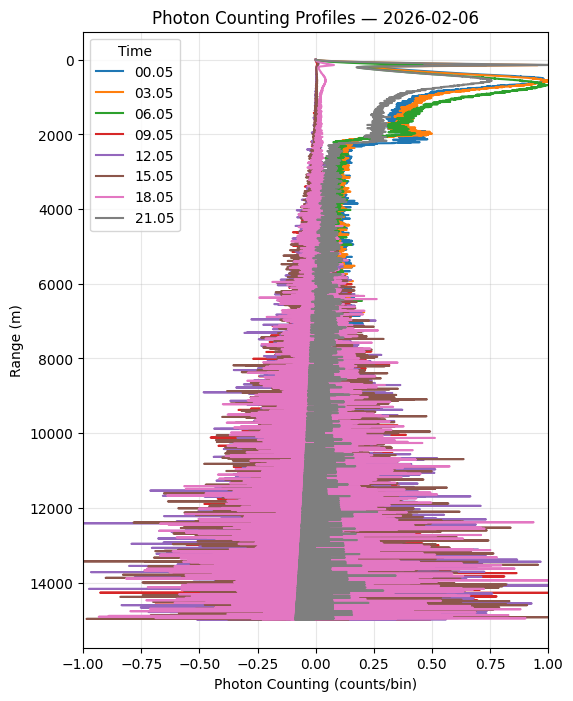

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# --- ensure datetime ---
df = df.copy()
df["date"] = pd.to_datetime(df["date"], errors="coerce")

# --- select date range ---
mask = df["date"].between(start_date, end_date, inclusive="both")
df_sel = df.loc[mask].copy()

# --- numeric range ---
df_sel["range_m"] = pd.to_numeric(df_sel["range_m"], errors="coerce")

# --- select every 3 hours ---
time_tags_3h = [f"{h:02d}.05" for h in range(0, 24, 3)]
# or use .35 depending on dataset
# time_tags_3h = [f"{h:02d}.35" for h in range(0, 24, 3)]

# --- one figure per day ---
for day, gday in df_sel.groupby(df_sel["date"].dt.date):

    fig, ax = plt.subplots(figsize=(6, 8), clear=True)

    for t in time_tags_3h:

        if t not in gday.columns:
            continue

        gg = gday.dropna(subset=["range_m", t]).copy()
        gg[t] = pd.to_numeric(gg[t], errors="coerce")
        gg = gg.dropna(subset=[t])

        ax.plot(
            gg[t].to_numpy(float),
            gg["range_m"].to_numpy(float),
            label=t
        )

    ax.invert_yaxis()
    ax.set_xlabel("Photon Counting (counts/bin)")
    ax.set_ylabel("Range (m)")
    ax.set_xlim(-1,1)
    ax.set_title(f"Photon Counting Profiles — {day}")
    ax.legend(title="Time")
    ax.grid(True, alpha=0.3)

    plt.show()

In [6]:
# --- ensure datetime + filter ---
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df_sel = df.loc[df["date"].between(start_date, end_date, inclusive="both")].copy()

# 4) Wide → long format
time_cols = [c for c in df_sel.columns if re.fullmatch(r"\d{1,2}\.\d{2}", str(c))]

df_long = df_sel.melt(
    id_vars=["date", "range_m"],
    value_vars=time_cols,
    var_name="time",
    value_name="signal"
)

bad_time = df_long.loc[~df_long["time"].astype(str).str.match(r"^\d{1,2}\.\d{2}$"), "time"]
print(bad_time.value_counts().head(30))

# 5) Build datetime (date + HH.MM)
df_long["datetime"] = pd.to_datetime(
    df_long["date"].dt.strftime("%Y-%m-%d") + " " +
    df_long["time"].astype(str).str.replace(".", ":", regex=False),
    format="%Y-%m-%d %H:%M",
    errors="coerce"
)

# 6) Pivot to 2D grid (range × time)
df_long = df_long.dropna(subset=["range_m", "signal", "datetime"])

# Use pivot_table (not pivot) to handle duplicate (range_m, datetime) entries
Z_nrb = df_long.pivot_table(
    index="range_m",
    columns="datetime",
    values="signal",
    aggfunc="mean"
).sort_index()

print(f"Z_nrb shape: {Z_nrb.shape}  ({Z_nrb.shape[0]} range bins × {Z_nrb.shape[1]} timestamps)")


Series([], Name: count, dtype: int64)
Z_nrb shape: (4000, 240)  (4000 range bins × 240 timestamps)


In [7]:
# def plot_lidar_curtain(Z_nrb, start_date, end_date, scale="log"):
#     """
#     Z_nrb : 2D DataFrame (range_m × datetime)
#     scale : "linear" or "log"
#     """

#     if scale == "log":
#         Z_plot = np.log10(Z_nrb.clip(lower=1e-6))
#         color_label = "log₁₀(Signal)"
#         title_scale = "log10"
#     elif scale == "linear":
#         Z_plot = Z_nrb.copy()
#         color_label = "Signal"
#         title_scale = "Linear"
#     else:
#         raise ValueError("scale must be 'linear' or 'log'")

#     plt.figure(figsize=(14, 6))

#     pcm = plt.pcolormesh(
#         Z_plot.columns,
#         Z_plot.index,
#         Z_plot.values,
#         shading="auto",
#         cmap="viridis"
#     )

#     plt.xlabel("Time")
#     plt.ylabel("Range (m)")
#     plt.title(
#         f"Lidar Backscatter ({title_scale}): "
#         f"{start_date:%d %b %Y}–{end_date:%d %b %Y}"
#     )

#     plt.colorbar(pcm, label=color_label)
#     plt.tight_layout()
#     plt.show()

In [8]:
# plot_lidar_curtain(Z_nrb, start_date, end_date, scale="log")

In [9]:
# plot_lidar_curtain(Z_nrb, start_date, end_date, scale="linear")

In [10]:
# START_DATE_STR = "02-02-2026"
# END_DATE_STR   = "06-02-2026"
# DATE_FORMAT = "%d-%m-%Y"

# start_date = pd.to_datetime(START_DATE_STR, format=DATE_FORMAT)
# end_date   = pd.to_datetime(END_DATE_STR, format=DATE_FORMAT)


In [11]:
def plot_lidar_curtain(
    Z_nrb,
    start_date,
    end_date,
    scale="log",
    save=True,
    save_dir="figures"
):
    """
    Z_nrb : 2D DataFrame (range_m × datetime)
    scale : "linear" or "log"
    save : True/False
    save_dir : folder to save figure
    """

    if scale == "log":
        Z_plot = np.log10(Z_nrb.clip(lower=1e-6))
        color_label = "log₁₀(Signal)"
        title_scale = "log10"
    elif scale == "linear":
        Z_plot = Z_nrb.copy()
        color_label = "Signal"
        title_scale = "Linear"
    else:
        raise ValueError("scale must be 'linear' or 'log'")

    fig, ax = plt.subplots(figsize=(14, 6))

    pcm = ax.pcolormesh(
        Z_plot.columns,
        Z_plot.index,
        Z_plot.values,
        shading="auto",
        cmap="viridis"
    )

    # --- Time formatting ---
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=6))
    ax.xaxis.set_major_formatter(
        mdates.DateFormatter('%d %b %Y\n%H:%M')
    )
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

    ax.set_xlabel("Time")
    ax.set_ylabel("Range (m)")
    plt.ylim(0, 15000)
    # # plt.xlim(200, 3000)
    # pcm.set_clim(-1.5, 0)
    ax.set_title(
        f"Lidar Backscatter ({title_scale}): "
        f"{start_date:%d %b %Y %H:%M} – {end_date:%d %b %Y %H:%M}"
    )

    fig.colorbar(pcm, ax=ax, label=color_label)
 
    plt.tight_layout()

    # --- Save section ---
    if save:
        os.makedirs(save_dir, exist_ok=True)

        filename = (
            f"lidar_{title_scale}_"
            f"{start_date:%Y%m%d_%H%M}_"
            f"{end_date:%Y%m%d_%H%M}.png"
        )

        save_path = os.path.join(save_dir, filename)
        fig.savefig(save_path, dpi=300, bbox_inches="tight")

        print(f"Saved figure → {save_path}")

    plt.show()


Saved figure → MyLidarFigures/lidar_log10_20260202_0000_20260206_0000.png


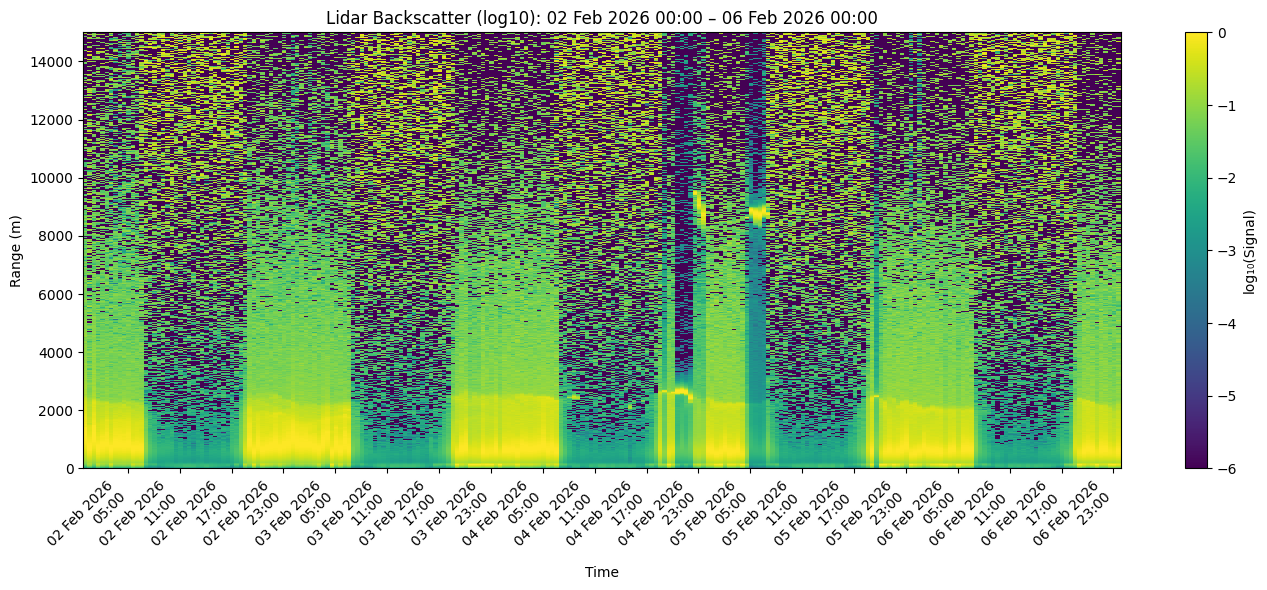

In [12]:
plot_lidar_curtain(
    Z_nrb,
    start_date,
    end_date,
    scale="log",
    save=True,
    save_dir="MyLidarFigures"
)

Saved figure → MyLidarFigures/lidar_Linear_20260202_0000_20260206_0000.png


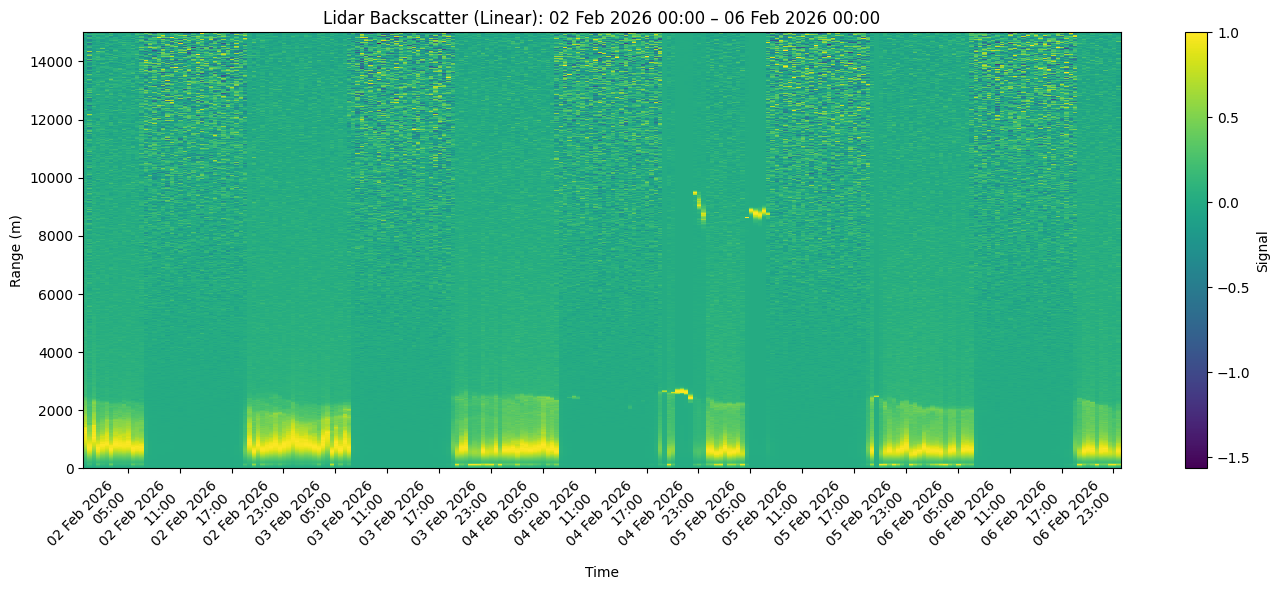

In [13]:
plot_lidar_curtain(
    Z_nrb,
    start_date,
    end_date,
    scale="linear",
    save=True,
    save_dir="MyLidarFigures"
)

In [14]:
def plot_lidar_curtain(
    Z_nrb,
    start_date,
    end_date,
    scale="log",
    save=True,
    save_dir="figures",
    ylim=None,
    xlim=None,
    clim=None,
    cmap="jet",
    invert_y=False,
):
    """
    Z_nrb : 2D DataFrame (range_m × datetime)

    scale : "linear" or "log"
    ylim  : tuple (ymin, ymax) or None
    xlim  : tuple (xmin, xmax) datetime or None
    clim  : tuple (vmin, vmax) or None
    cmap  : matplotlib colormap
    invert_y : True/False
    """

    import os
    import numpy as np
    import matplotlib.pyplot as plt
    import matplotlib.dates as mdates
    from datetime import timedelta

    # --- Scale handling ---
    if scale == "log":
        Z_plot = np.log10(Z_nrb.clip(lower=1e-6))
        color_label = "log₁₀(Signal)"
        title_scale = "log10"
    elif scale == "linear":
        Z_plot = Z_nrb.copy()
        color_label = "Signal"
        title_scale = "Linear"
    else:
        raise ValueError("scale must be 'linear' or 'log'")

    fig, ax = plt.subplots(figsize=(8, 6))

    pcm = ax.pcolormesh(
        Z_plot.columns,
        Z_plot.index,
        Z_plot.values,
        shading="auto",
        cmap=cmap
    )

    # --- Time formatting ---
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=12))
    ax.xaxis.set_major_formatter(
        mdates.DateFormatter('%d %b %Y\n%H:%M')
    )
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

    ax.set_xlabel("Time")
    ax.set_ylabel("Range (m)")

    # --- Optional axis limits ---
    if ylim is not None:
        ax.set_ylim(ylim)

    if xlim is not None:
        ax.set_xlim(xlim)

    if invert_y:
        ax.invert_yaxis()

    # --- Optional color limits ---
    if clim is not None:
        pcm.set_clim(*clim)
        
    end_date_fixed = end_date.replace(hour=23, minute=59)
    
    ax.set_title(
        f"Lidar Backscatter ({title_scale}): "
        f"{start_date:%d %b %Y %H:%M} – {end_date_fixed:%d %b %Y %H:%M}"
    )

    fig.colorbar(pcm, ax=ax, label=color_label)

    plt.tight_layout()

    # --- Save section ---
    if save:
        os.makedirs(save_dir, exist_ok=True)

        filename = (
            f"lidar_{title_scale}_Pro"
            f"{start_date:%Y%m%d_%H%M}_"
            f"{(end_date + timedelta(days=1)):%Y%m%d_%H%M}.png"
        )

        save_path = os.path.join(save_dir, filename)
        fig.savefig(save_path, dpi=300, bbox_inches="tight")

        print(f"Saved figure → {save_path}")

    plt.show()


Saved figure → figures/lidar_Linear_Pro20260202_0000_20260207_0000.png


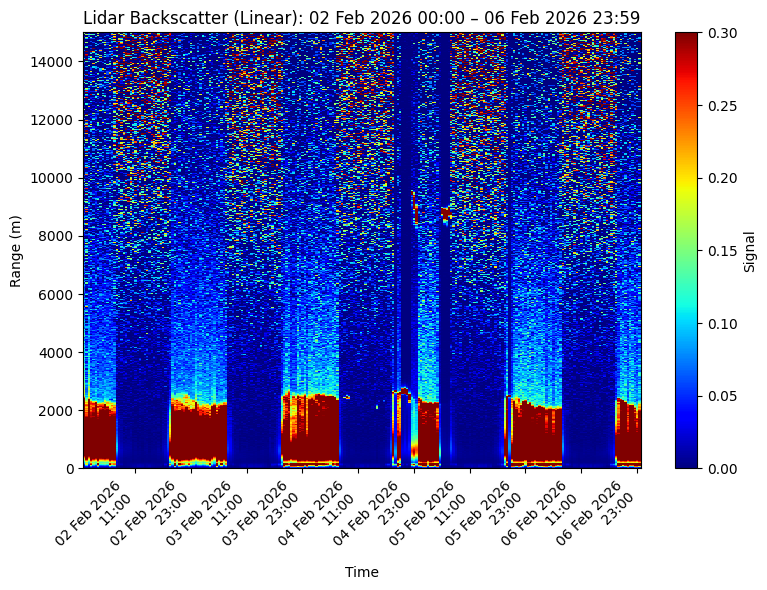

In [15]:
plot_lidar_curtain(
    Z_nrb,
    start_date,
    end_date,
    scale="linear",
    ylim=(0, 15000),
    clim=(0, 0.3)
)

Saved figure → figures/lidar_Linear_Pro20260202_0000_20260207_0000.png


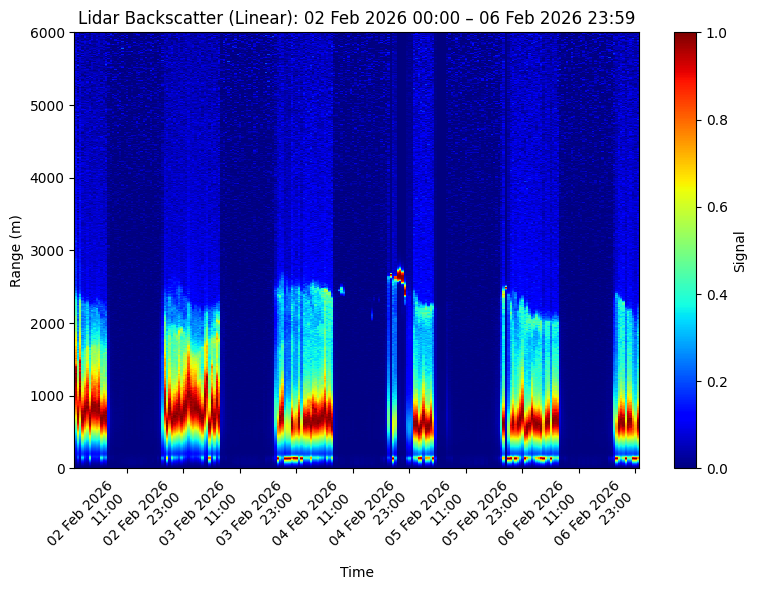

In [16]:
plot_lidar_curtain(
    Z_nrb,
    start_date,
    end_date,
    scale="linear",
    ylim=(0, 6000),
    clim=(0, 1)
)

Saved figure → figures/lidar_Linear_Pro20260202_0000_20260207_0000.png


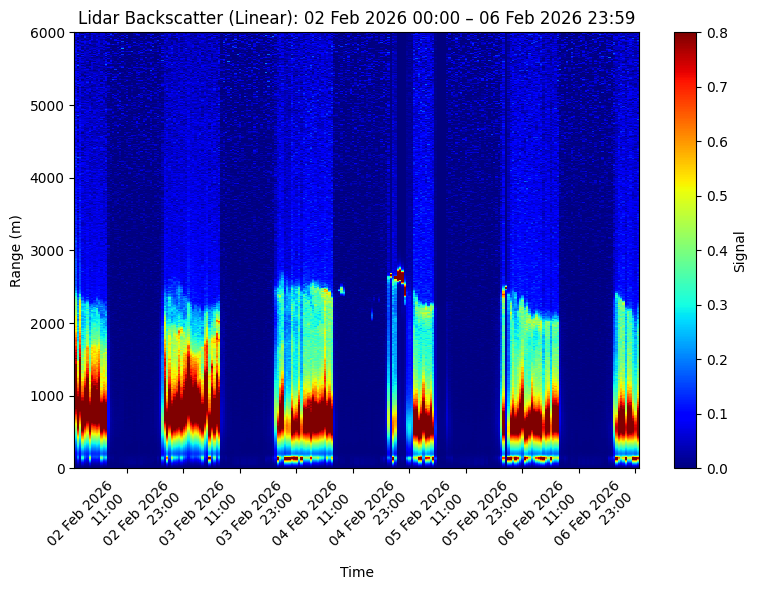

In [17]:
plot_lidar_curtain(
    Z_nrb,
    start_date,
    end_date,
    scale="linear",
    ylim=(0, 6000),
    clim=(0, 0.8)
)

Saved figure → figures/lidar_Linear_Pro20260202_0000_20260207_0000.png


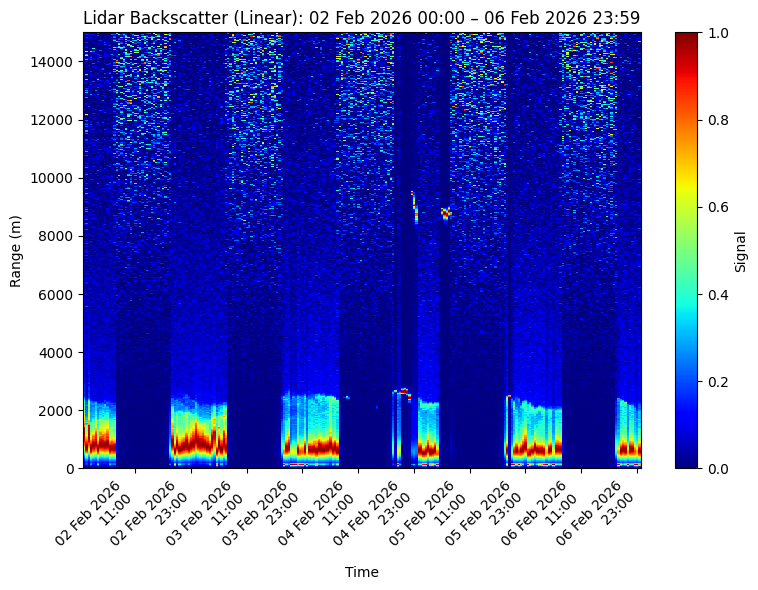

In [18]:
plot_lidar_curtain(
    Z_nrb,
    start_date,
    end_date,
    scale="linear",
    ylim=(0, 15000),
    clim=(0, 1)
)

Saved figure → figures/lidar_Linear_Pro20260202_0000_20260207_0000.png


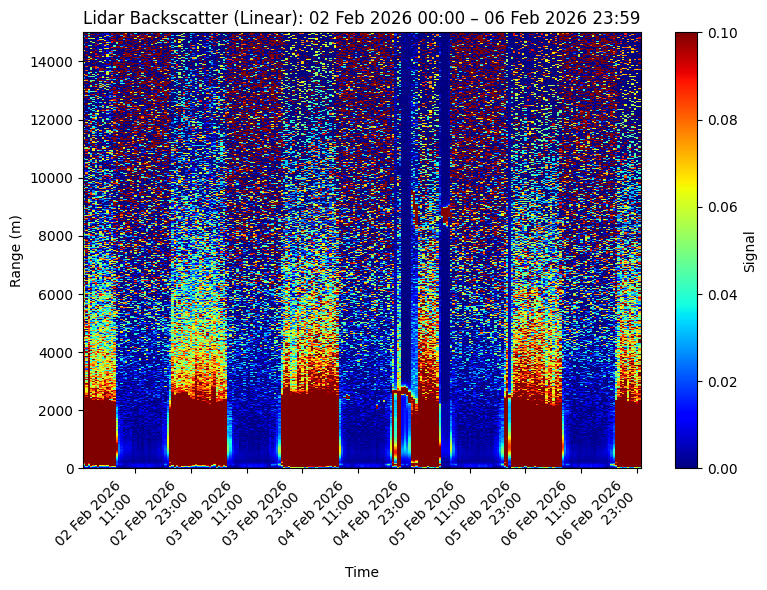

In [19]:
plot_lidar_curtain(
    Z_nrb,
    start_date,
    end_date,
    scale="linear",
    ylim=(0, 15000),
    clim=(0, 0.1)
)

Saved figure → figures/lidar_Linear_Pro20260202_0000_20260207_0000.png


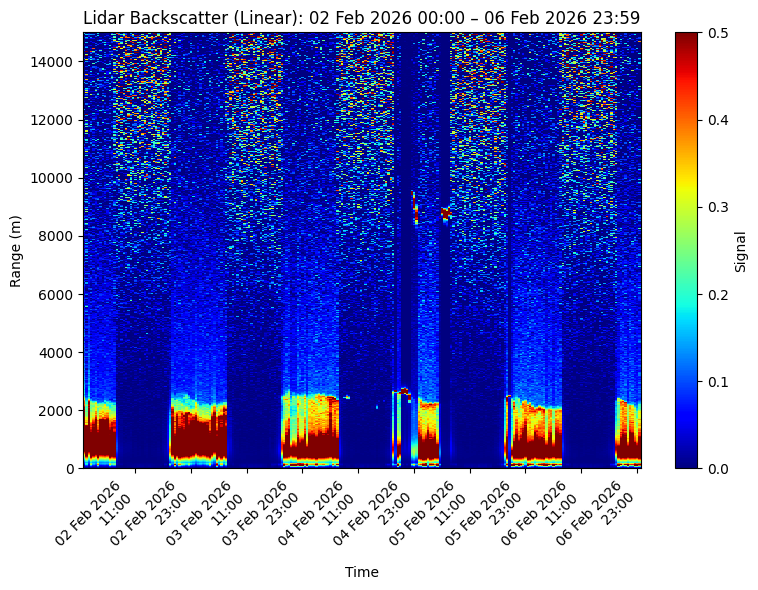

In [20]:
plot_lidar_curtain(
    Z_nrb,
    start_date,
    end_date,
    scale="linear",
    ylim=(0, 15000),
    clim=(0, 0.5)
)

Saved figure → figures/lidar_Linear_Pro20260202_0000_20260207_0000.png


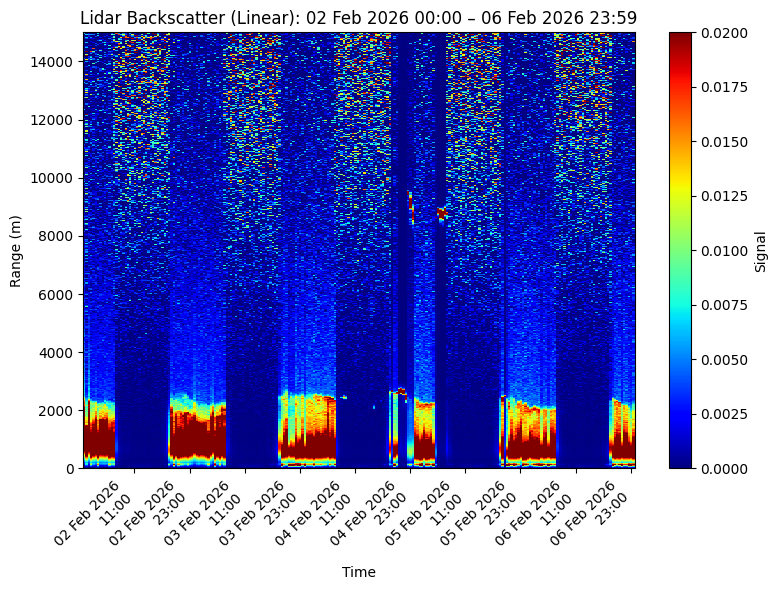

In [21]:
plot_lidar_curtain(
    Z_nrb/25,
    start_date,
    end_date,
    scale="linear",
    ylim=(0, 15000),
    clim=(0, 0.02)
)